# NV Diamond Pulse Data Analysis

This notebook analyzes new measurement data from `.npy` files in the `Avg_npy_pulse` folder. Each file corresponds to one crystallographic direction in an NV- 100 faced diamond. The notebook will:
- Examine the data structure and determine the number of pixels
- Visualize time traces for each pixel and direction
- Reconstruct the 2D pixel grid (zig-zag order)
- Visualize the spatial distribution at selected time points

**Data structure:**
- Each `.npy` file: 2D array, first column is time (seconds), remaining columns are pixel voltages (units: volts or as specified)
- Four files: one per crystallographic direction


In [70]:
# Import Required Libraries and Set Up Paths
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Set the folder path containing the .npy files
folder = 'Avg_npy_pulse'

# List all .npy files (one per crystallographic direction)
npy_files = sorted(glob.glob(os.path.join(folder, 'Pulse_avg_d*.npy')))
print('Found files:', npy_files)


Found files: ['Avg_npy_pulse/Pulse_avg_d1.npy', 'Avg_npy_pulse/Pulse_avg_d2.npy', 'Avg_npy_pulse/Pulse_avg_d3.npy', 'Avg_npy_pulse/Pulse_avg_d4.npy']


## Load and Inspect Data Files

Load each .npy file, print its shape, and display the first few rows to understand the structure. Confirm that the first column is time and the rest are pixel voltages.

In [71]:
# Load each .npy file, print shape and first few rows
all_data = []
for f in npy_files:
    arr = np.load(f)
    print(f"File: {os.path.basename(f)} | Shape: {arr.shape}")
    print("First 3 rows:\n", arr[:3])
    all_data.append(arr)
    print("---")
# Confirm: arr[:, 0] is time, arr[:, 1:] are pixel voltages

File: Pulse_avg_d1.npy | Shape: (457, 962)
First 3 rows:
 [[ 0.00000000e+00  7.94575342e+01  9.79260173e+01 ...  5.02662066e+01
   1.83949340e+02  2.60874027e+02]
 [ 3.86400000e-04  6.97000215e+01  7.90484173e+01 ...  5.74127265e+01
   1.92701682e+02  2.00465708e+02]
 [ 7.72800000e-04  6.78735524e+01  1.19341061e+02 ... -2.67764658e+01
   1.81571253e+02  2.52918467e+02]]
---
File: Pulse_avg_d2.npy | Shape: (457, 962)
First 3 rows:
 [[0.00000000e+00 1.40353527e+01 4.02364506e+00 ... 6.39354888e+01
  4.24899231e+01 1.02095369e+02]
 [3.86400000e-04 2.03529379e+01 2.75272821e+01 ... 4.39097611e+01
  1.35727491e+02 1.21714107e+02]
 [7.72800000e-04 2.02419408e+01 3.76465182e+01 ... 3.91368855e+01
  1.41268097e+02 1.45217744e+02]]
---
File: Pulse_avg_d3.npy | Shape: (457, 962)
First 3 rows:
 [[ 0.00000000e+00  4.67520757e+00 -3.00801733e+01 ...  3.49169467e+01
  -2.23777305e+01 -1.00303526e+02]
 [ 3.86400000e-04 -6.49443985e+01 -8.37931891e+00 ... -1.02534836e+01
  -8.51367373e+00 -1.01528025

## Determine Number of Pixels and Data Shape

For one file, extract the number of pixels by checking the number of columns minus one (for time). Print the number of pixels and check if it matches 31x31. Print the time vector shape and pixel trace shape.

In [72]:
# Analyze shape for one file (first direction)
arr = all_data[0]
time = arr[:, 0]
traces = arr[:, 1:]
n_timepoints, n_pixels = traces.shape
print(f"Number of pixels: {n_pixels}")
print(f"Is it a square? sqrt({n_pixels}) = {np.sqrt(n_pixels)}")
print(f"Time vector shape: {time.shape}")
print(f"Pixel traces shape: {traces.shape}")

Number of pixels: 961
Is it a square? sqrt(961) = 31.0
Time vector shape: (457,)
Pixel traces shape: (457, 961)


In [73]:
# Extract time and voltage matrices from the loaded files

time = all_data[0][:, 0]

voltage_d1 = all_data[0][:, 1:]
voltage_d2 = all_data[1][:, 1:]
voltage_d3 = all_data[2][:, 1:]
voltage_d4 = all_data[3][:, 1:]

print("time shape:", time.shape)
print("d1 shape:", voltage_d1.shape)
print("d2 shape:", voltage_d2.shape)
print("d3 shape:", voltage_d3.shape)
print("d4 shape:", voltage_d4.shape)

voltage_stack = np.stack([voltage_d1, voltage_d2, voltage_d3, voltage_d4], axis=0)

print("voltage_stack shape:", voltage_stack.shape)
print("Channel order: d1, d2, d3, d4")

time shape: (457,)
d1 shape: (457, 961)
d2 shape: (457, 961)
d3 shape: (457, 961)
d4 shape: (457, 961)
voltage_stack shape: (4, 457, 961)
Channel order: d1, d2, d3, d4


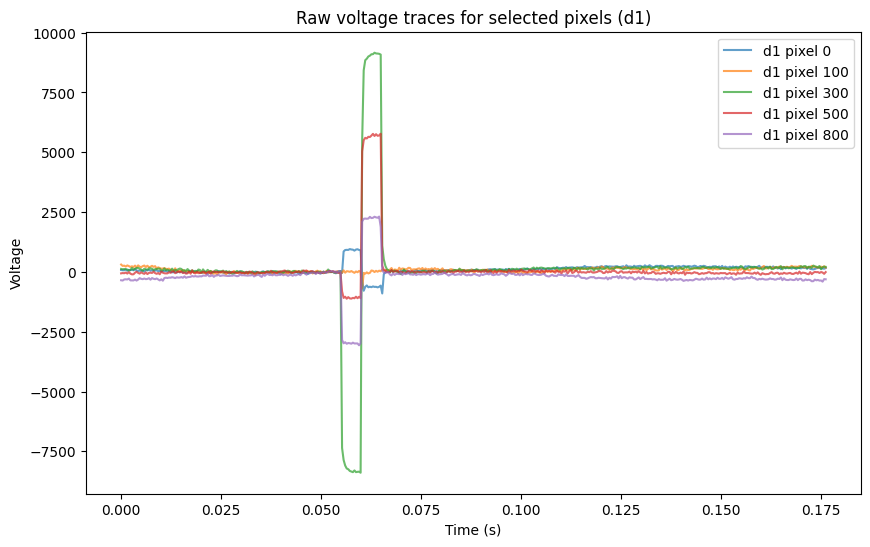

In [74]:
# Plot raw traces for a few example pixels
pixel_list = [0, 100, 300, 500, 800]

plt.figure(figsize=(10, 6))

for pixel_idx in pixel_list:
    plt.plot(time, voltage_d1[:, pixel_idx], alpha=0.7, label=f'd1 pixel {pixel_idx}')

plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Raw voltage traces for selected pixels (d1)')
plt.legend()
plt.show()

baseline subtraction


In [75]:
# Baseline subtraction using the first few time points
baseline_n = 20

baseline = np.mean(voltage_stack[:, :baseline_n, :], axis=1, keepdims=True)
delta_voltage = voltage_stack - baseline

print("baseline shape:", baseline.shape)
print("delta_voltage shape:", delta_voltage.shape)

baseline shape: (4, 1, 961)
delta_voltage shape: (4, 457, 961)


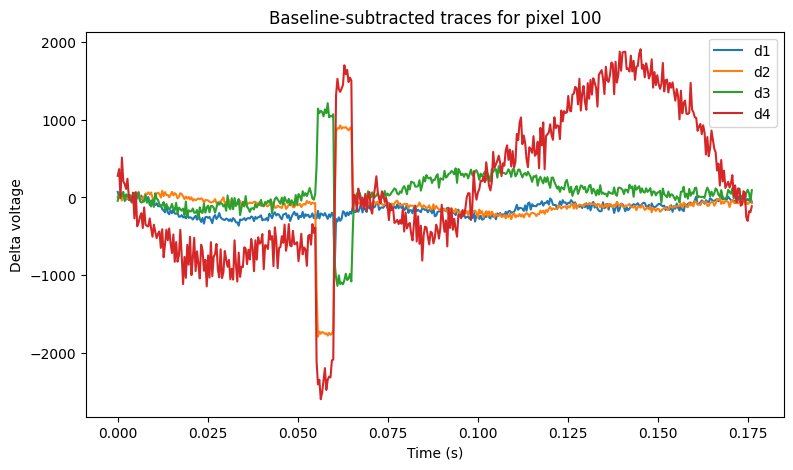

In [76]:
# Plot baseline-subtracted traces for one pixel
pixel_idx = 100

plt.figure(figsize=(9, 5))
plt.plot(time, delta_voltage[0, :, pixel_idx], label='d1')
plt.plot(time, delta_voltage[1, :, pixel_idx], label='d2')
plt.plot(time, delta_voltage[2, :, pixel_idx], label='d3')
plt.plot(time, delta_voltage[3, :, pixel_idx], label='d4')
plt.xlabel('Time (s)')
plt.ylabel('Delta voltage')
plt.title(f'Baseline-subtracted traces for pixel {pixel_idx}')
plt.legend()
plt.show()

In [77]:
# --- Set pixel index and time indices for analysis ---
pixel_idx = 100  # pixel to analyze

t1 = 0.0005  # time in seconds for first interval
nt2 = 0.0015  # time in seconds for second interval

# Find the closest indices in the time array
time_idx_pos = (np.abs(time - t1)).argmin()
time_idx_neg = (np.abs(time - nt2)).argmin()

print(f"Selected pixel: {pixel_idx}")
print(f"t1 = {t1} s (index {time_idx_pos})")
print(f"t2 = {nt2} s (index {time_idx_neg})")


Selected pixel: 100
t1 = 0.0005 s (index 1)
t2 = 0.0015 s (index 4)


## reconstruct greed



In [78]:
# Reconstruct the 2D pixel grid from 1D pixel index
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx

print("Grid mapping (pixel indices):")
print(grid)

Grid mapping (pixel indices):
[[960 899 898 837 836 775 774 713 712 651 650 589 588 527 526 465 464 403
  402 341 340 279 278 217 216 155 154  93  92  31  30]
 [959 900 897 838 835 776 773 714 711 652 649 590 587 528 525 466 463 404
  401 342 339 280 277 218 215 156 153  94  91  32  29]
 [958 901 896 839 834 777 772 715 710 653 648 591 586 529 524 467 462 405
  400 343 338 281 276 219 214 157 152  95  90  33  28]
 [957 902 895 840 833 778 771 716 709 654 647 592 585 530 523 468 461 406
  399 344 337 282 275 220 213 158 151  96  89  34  27]
 [956 903 894 841 832 779 770 717 708 655 646 593 584 531 522 469 460 407
  398 345 336 283 274 221 212 159 150  97  88  35  26]
 [955 904 893 842 831 780 769 718 707 656 645 594 583 532 521 470 459 408
  397 346 335 284 273 222 211 160 149  98  87  36  25]
 [954 905 892 843 830 781 768 719 706 657 644 595 582 533 520 471 458 409
  396 347 334 285 272 223 210 161 148  99  86  37  24]
 [953 906 891 844 829 782 767 720 705 658 643 596 581 534 519 472 4

In [79]:
import pandas as pd
from pathlib import Path

A_path = Path("nv_to_lab_frame/outputs/A_numerical_MHz_per_mT.csv")
A_df = pd.read_csv(A_path, index_col=0)

print(A_df)

           Bx         By         Bz
d3  22.566028   1.400895  16.617418
d2  -1.737286 -22.678087  16.453223
d4  22.026210   1.388730 -17.363592
d1  -1.718851 -22.134986 -17.192367


In [80]:
A = A_df.loc[["d1", "d2", "d3", "d4"], ["Bx", "By", "Bz"]].to_numpy(dtype=float)
A_pinv = np.linalg.pinv(A)

print("A shape:", A.shape)
print("A_pinv shape:", A_pinv.shape)
print("A [MHz/mT]:\n", A)
print("A_pinv [mT/MHz]:\n", A_pinv)

A shape: (4, 3)
A_pinv shape: (3, 4)
A [MHz/mT]:
 [[ -1.71885091 -22.13498623 -17.19236694]
 [ -1.7372858  -22.67808659  16.4532228 ]
 [ 22.5660281    1.40089474  16.61741761]
 [ 22.02620978   1.38872996 -17.3635923 ]]
A_pinv [mT/MHz]:
 [[ 0.0012608   0.00154093  0.02291588  0.02214288]
 [-0.02203343 -0.02280328 -0.00188058 -0.00159132]
 [-0.01489524  0.01452335  0.01466775 -0.01504409]]


In [81]:
# Slopes: dV/dnu
# Units: Voltage per MHz - This is a crucial parameter that relates changes in the measured voltage to changes in the resonance frequency

slope_d1_V_per_MHz = 1.0
slope_d2_V_per_MHz = 1.0
slope_d3_V_per_MHz = 1.0
slope_d4_V_per_MHz = 1.0

slopes_V_per_MHz = np.array([
    slope_d1_V_per_MHz,
    slope_d2_V_per_MHz,
    slope_d3_V_per_MHz,
    slope_d4_V_per_MHz
], dtype=float)

print("Slopes [V/MHz]:", slopes_V_per_MHz)

# Convert delta voltage to delta nu
# Output units: MHz

delta_nu = np.zeros_like(delta_voltage, dtype=float)

delta_nu[0, :, :] = delta_voltage[0, :, :] / slopes_V_per_MHz[0]
delta_nu[1, :, :] = delta_voltage[1, :, :] / slopes_V_per_MHz[1]
delta_nu[2, :, :] = delta_voltage[2, :, :] / slopes_V_per_MHz[2]
delta_nu[3, :, :] = delta_voltage[3, :, :] / slopes_V_per_MHz[3]

print("delta_nu shape:", delta_nu.shape)
print("Units: MHz")

Slopes [V/MHz]: [1. 1. 1. 1.]
delta_nu shape: (4, 457, 961)
Units: MHz


In [82]:
# Reconstruct Bx, By, Bz from delta_nu using A_pinv
# Output units: mT

n_dirs, n_timepoints, n_pixels = delta_nu.shape
B_lab = np.zeros((3, n_timepoints, n_pixels), dtype=float)

for t_idx in range(n_timepoints):
    for p_idx in range(n_pixels):
        nu_vec = delta_nu[:, t_idx, p_idx]
        B_vec = A_pinv @ nu_vec
        B_lab[:, t_idx, p_idx] = B_vec

print("B_lab shape:", B_lab.shape)
print("Component order: Bx, By, Bz")
print("Units: mT")

B_lab shape: (3, 457, 961)
Component order: Bx, By, Bz
Units: mT


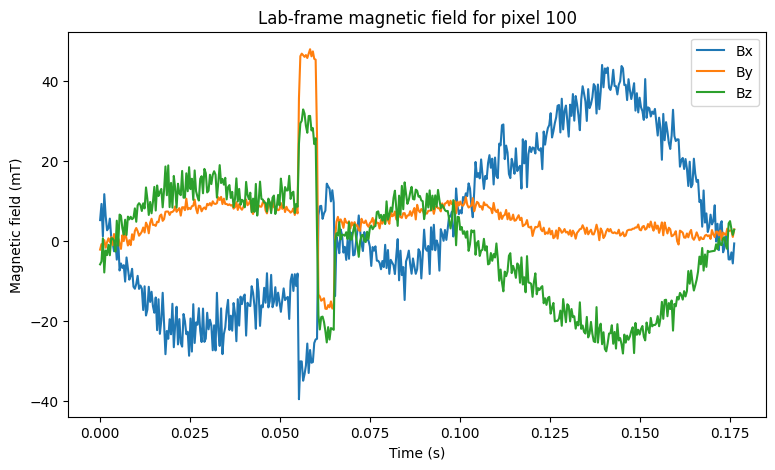

In [83]:
# Plot Bx, By, Bz for one pixel
pixel_idx = 100

plt.figure(figsize=(9, 5))
plt.plot(time, B_lab[0, :, pixel_idx], label='Bx')
plt.plot(time, B_lab[1, :, pixel_idx], label='By')
plt.plot(time, B_lab[2, :, pixel_idx], label='Bz')
plt.xlabel('Time (s)')
plt.ylabel('Magnetic field (mT)')
plt.title(f'Lab-frame magnetic field for pixel {pixel_idx}')
plt.legend()
plt.show()

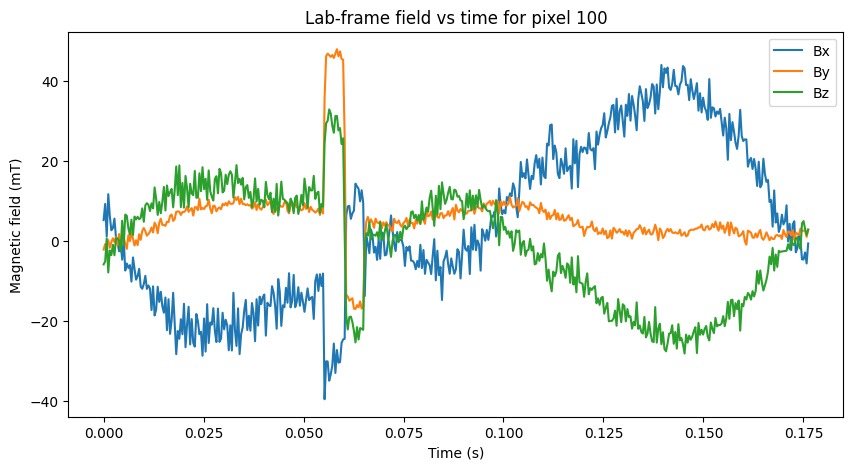

In [84]:
# Inspect one pixel to choose time indices for positive and negative pulse intervals
pixel_idx = 100

plt.figure(figsize=(10, 5))
plt.plot(time, B_lab[0, :, pixel_idx], label='Bx')
plt.plot(time, B_lab[1, :, pixel_idx], label='By')
plt.plot(time, B_lab[2, :, pixel_idx], label='Bz')
plt.xlabel('Time (s)')
plt.ylabel('Magnetic field (mT)')
plt.title(f'Lab-frame field vs time for pixel {pixel_idx}')
plt.legend()
plt.show()

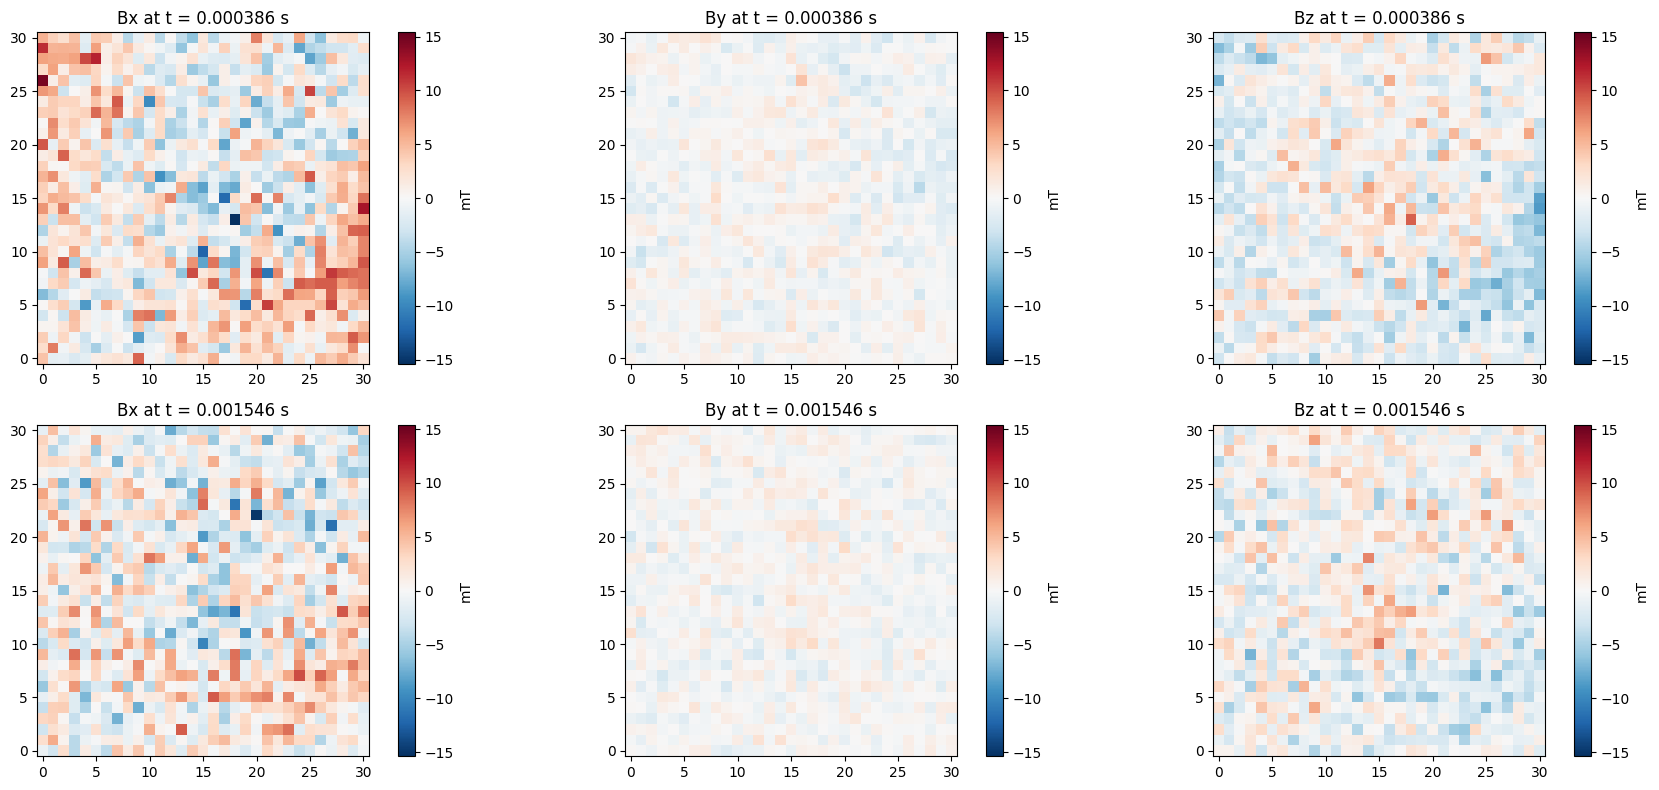

In [85]:
# Visualize Bx, By, Bz maps at two selected time indices
# No averaging: each panel is one exact time sample

Bx_img_pos = np.zeros((grid_size, grid_size), dtype=float)
By_img_pos = np.zeros((grid_size, grid_size), dtype=float)
Bz_img_pos = np.zeros((grid_size, grid_size), dtype=float)

Bx_img_neg = np.zeros((grid_size, grid_size), dtype=float)
By_img_neg = np.zeros((grid_size, grid_size), dtype=float)
Bz_img_neg = np.zeros((grid_size, grid_size), dtype=float)

for y in range(grid_size):
    for x in range(grid_size):
        idx = grid[y, x]

        Bx_img_pos[y, x] = B_lab[0, time_idx_pos, idx]
        By_img_pos[y, x] = B_lab[1, time_idx_pos, idx]
        Bz_img_pos[y, x] = B_lab[2, time_idx_pos, idx]

        Bx_img_neg[y, x] = B_lab[0, time_idx_neg, idx]
        By_img_neg[y, x] = B_lab[1, time_idx_neg, idx]
        Bz_img_neg[y, x] = B_lab[2, time_idx_neg, idx]

absmax = np.max(np.abs([
    Bx_img_pos, By_img_pos, Bz_img_pos,
    Bx_img_neg, By_img_neg, Bz_img_neg
]))

plt.figure(figsize=(18, 8))

plt.subplot(2, 3, 1)
plt.imshow(Bx_img_pos, origin='lower', cmap='RdBu_r', vmin=-absmax, vmax=absmax)
plt.colorbar(label='mT')
plt.title(f'Bx at t = {time[time_idx_pos]:.6f} s')

plt.subplot(2, 3, 2)
plt.imshow(By_img_pos, origin='lower', cmap='RdBu_r', vmin=-absmax, vmax=absmax)
plt.colorbar(label='mT')
plt.title(f'By at t = {time[time_idx_pos]:.6f} s')

plt.subplot(2, 3, 3)
plt.imshow(Bz_img_pos, origin='lower', cmap='RdBu_r', vmin=-absmax, vmax=absmax)
plt.colorbar(label='mT')
plt.title(f'Bz at t = {time[time_idx_pos]:.6f} s')

plt.subplot(2, 3, 4)
plt.imshow(Bx_img_neg, origin='lower', cmap='RdBu_r', vmin=-absmax, vmax=absmax)
plt.colorbar(label='mT')
plt.title(f'Bx at t = {time[time_idx_neg]:.6f} s')

plt.subplot(2, 3, 5)
plt.imshow(By_img_neg, origin='lower', cmap='RdBu_r', vmin=-absmax, vmax=absmax)
plt.colorbar(label='mT')
plt.title(f'By at t = {time[time_idx_neg]:.6f} s')

plt.subplot(2, 3, 6)
plt.imshow(Bz_img_neg, origin='lower', cmap='RdBu_r', vmin=-absmax, vmax=absmax)
plt.colorbar(label='mT')
plt.title(f'Bz at t = {time[time_idx_neg]:.6f} s')

plt.tight_layout()
plt.show()


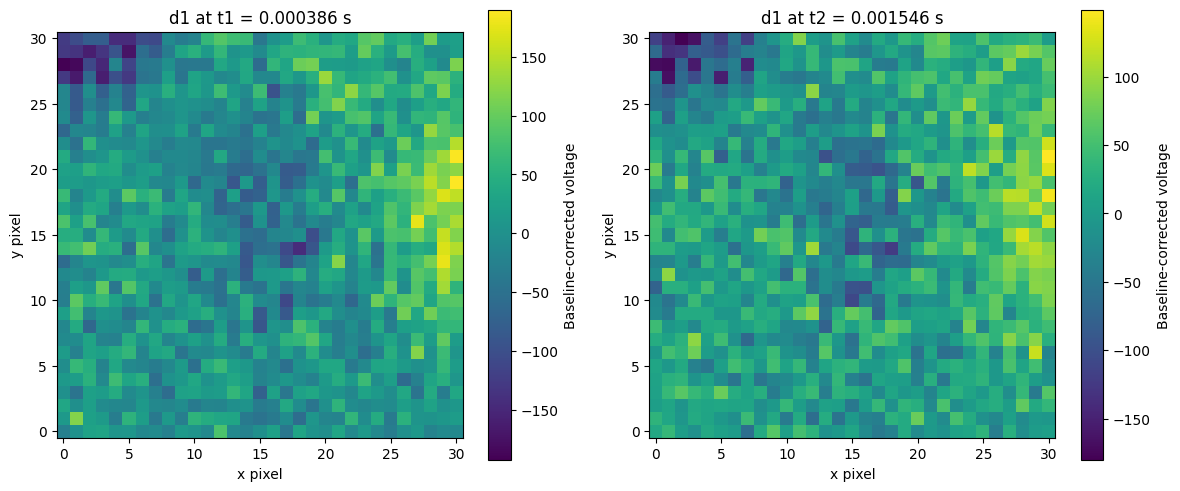

In [86]:
direction_idx = 0   # choose which direction to display here

arr = all_data[direction_idx]
time = arr[:, 0]
traces = arr[:, 1:]

# baseline-correct
baseline = np.mean(traces[:40, :], axis=0)
traces_corr = traces - baseline

img_t1 = np.zeros_like(grid, dtype=float)
img_t2 = np.zeros_like(grid, dtype=float)

for y in range(grid_size):
    for x in range(grid_size):
        idx = grid[y, x]
        img_t1[y, x] = traces_corr[time_idx_pos, idx]
        img_t2[y, x] = traces_corr[time_idx_neg, idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(img_t1, cmap='viridis', origin='lower')
axes[0].set_title(f'd{direction_idx+1} at t1 = {time[time_idx_pos]:.6f} s')
axes[0].set_xlabel('x pixel')
axes[0].set_ylabel('y pixel')
plt.colorbar(im0, ax=axes[0], label='Baseline-corrected voltage')

im1 = axes[1].imshow(img_t2, cmap='viridis', origin='lower')
axes[1].set_title(f'd{direction_idx+1} at t2 = {time[time_idx_neg]:.6f} s')
axes[1].set_xlabel('x pixel')
axes[1].set_ylabel('y pixel')
plt.colorbar(im1, ax=axes[1], label='Baseline-corrected voltage')

plt.tight_layout()
plt.show()
